In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'f(x) = sin(x)')

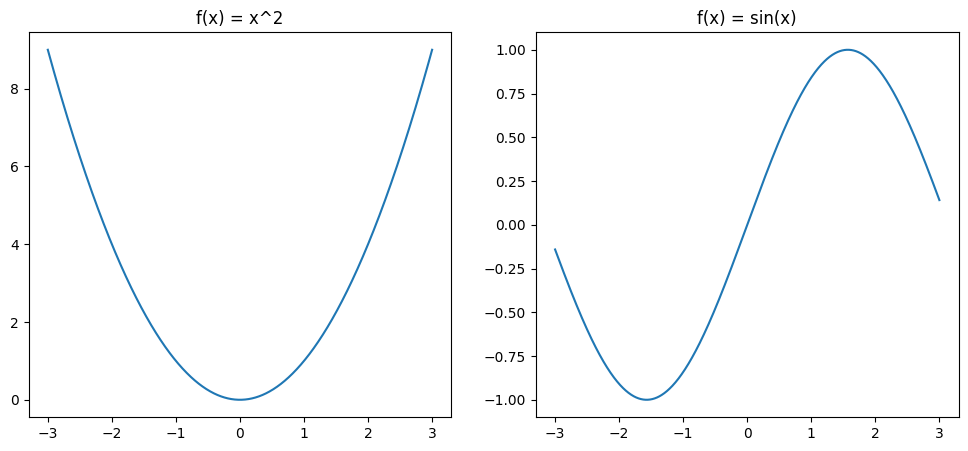

In [2]:
x = np.linspace(-3, 3, 1000)

def f1(x): return x**2
def f2(x): return np.sin(x)

fig, axes = plt.subplots(1,2, figsize = (12,5))
axes[0].plot(x, f1(x))
axes[0].set_title('f(x) = x^2')
axes[1].plot(x, f2(x))
axes[1].set_title('f(x) = sin(x)')

In [3]:
def derivative(f, x, h=0.00001):
    return (f(x+h) - (f(x))) / h

print(f"f1'(2) = {derivative(f1, 2):.6f}  expected: 4.0")
print(f"f2'(0) = {derivative(f2, 0):.6f}  expected: 1.0")

f1'(2) = 4.000010  expected: 4.0
f2'(0) = 1.000000  expected: 1.0


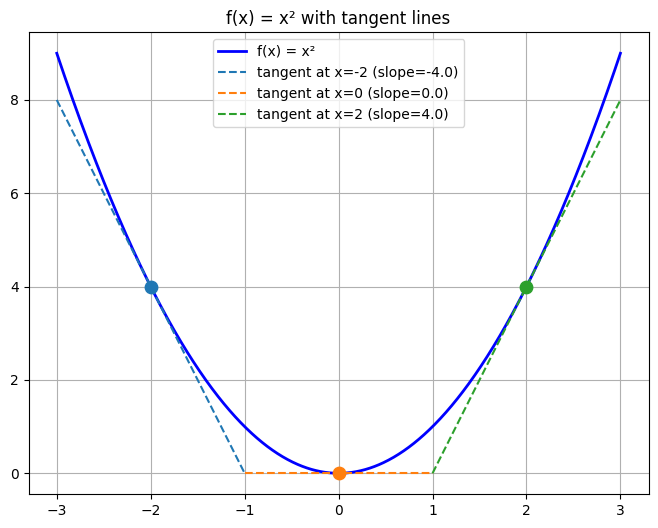

In [4]:
def tangent_line(f, x0, x):
    slope = derivative(f, x0)
    return f(x0) + slope * (x - x0)

x_points = [-2, 0 ,2]


plt.figure(figsize=(8, 6))
plt.plot(x, f1(x), 'b-', label='f(x) = x²', linewidth=2)

for x0 in x_points:
    x_tangent = np.linspace(x0 - 1, x0 + 1, 100)
    plt.plot(x_tangent, tangent_line(f1, x0, x_tangent), '--', label=f"tangent at x={x0} (slope={derivative(f1,x0):.1f})")
    plt.scatter([x0], [f1(x0)], s=80, zorder=5)
plt.legend()
plt.title('f(x) = x² with tangent lines')
plt.grid(True)
plt.show()


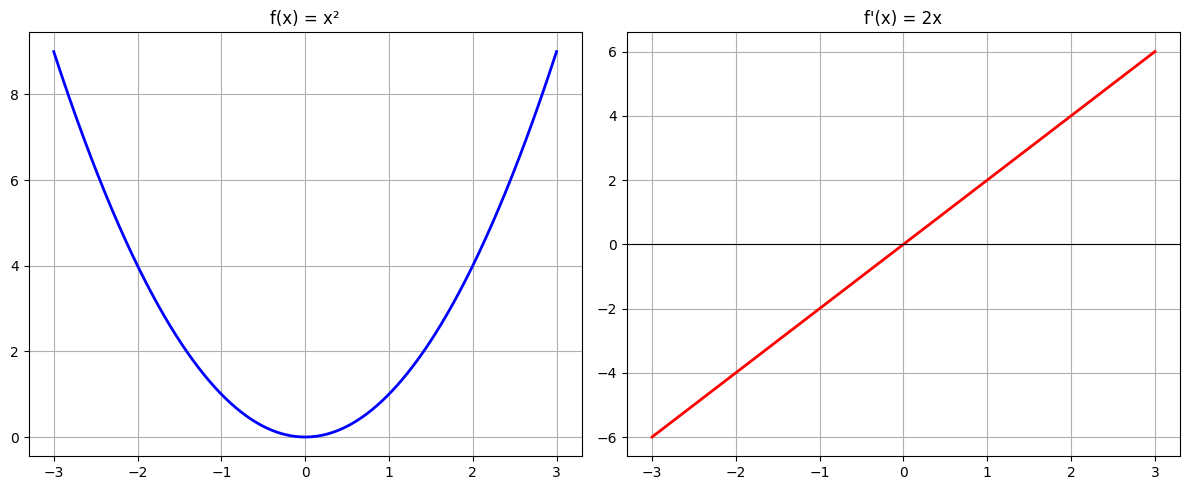

In [6]:
dx = np.array([derivative(f1, xi) for xi in x])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original function
axes[0].plot(x, f1(x), 'b-', linewidth=2)
axes[0].set_title('f(x) = x²')
axes[0].grid(True)

# Right: derivative at every point
axes[1].plot(x, dx, 'r-', linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title("f'(x) = 2x")
axes[1].grid(True)

plt.tight_layout()

Numerical derivative of f(g(x)) at x=1: 0.909293
Chain rule result:                       0.909296
Match: True


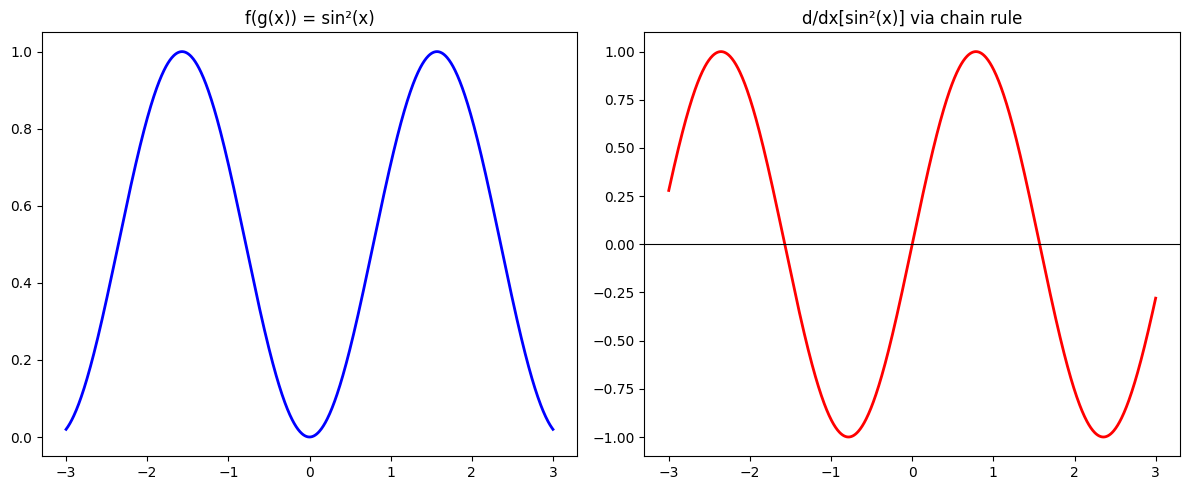

In [7]:
def g(x): return np.sin(x)
def fog(x): return f1(g(x))

def chain_rule(f, g, x):
    return derivative(f, g(x)) * derivative(g, x)

# Verify against numerical derivative of the composed function
x_test = 1.0
numerical = derivative(fog, x_test)
chain     = chain_rule(f1, g, x_test)
print(f"Numerical derivative of f(g(x)) at x=1: {numerical:.6f}")
print(f"Chain rule result:                       {chain:.6f}")
print(f"Match: {abs(numerical - chain) < 0.001}")

# Plot composed function vs its derivative
chain_dx = np.array([chain_rule(f1, g, xi) for xi in x])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(x, fog(x), 'b-', linewidth=2)
axes[0].set_title('f(g(x)) = sin²(x)')
axes[1].plot(x, chain_dx, 'r-', linewidth=2)
axes[1].set_title("d/dx[sin²(x)] via chain rule")
axes[1].axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()